# 02 Classify: lawn per parcel, per year

Each year is classified on its own. That is deliberate: the NAIP years were flown by
different cameras on different dates and are not radiometrically consistent, so we never
difference NDVI across years. We only ever compare *areas* that each year's classification produced.

For every image year:

1. NDVI from the red and NIR bands, plus a brightness value for shadow screening.
2. Eligible pixels = inside an (inset) parcel, not canopy or structure per the lidar,
   not building, not water, not deep shadow. This is the denominator.
3. Lawn = eligible pixels with NDVI above the year's threshold. The threshold comes from
   Otsu on the eligible pixels unless `config.yaml` fixes it or a training layer exists
   for the year (then a random forest is used instead).
4. Speckle removal: 3x3 majority filter, then drop patches under the minimum mapping unit.
5. Tabulate lawn, eligible, canopy, building, water, and shadow area by parcel.

Outputs: `data/processed/lawn_<year>.tif`, `outputs/lawn_by_parcel_<year>.csv`, and the long
table `data/processed/lawn_by_parcel_all_years.parquet` that notebook 03 consumes.

In [1]:
import sys
from pathlib import Path

print(sys.executable)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.io import load_config, get_logger
from src import grid as G
from src import qa

cfg = load_config()
log = get_logger("02_classify")

RAW = ROOT / cfg["paths"]["raw"]
PROC = ROOT / cfg["paths"]["processed"]
OUT = ROOT / cfg["paths"]["outputs"]
OUT.mkdir(exist_ok=True)
A = cfg["analysis"]

/usr/bin/python3


2026-09-17 21:38:13 | INFO | 02_classify | Log file: <repo>/logs/02_classify_2026-09-17_213813.log


In [2]:
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from scipy import ndimage
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

grid = G.load_grid(PROC / "grid.json")
PX_M2 = G.pixel_area_m2(grid)
naip_index = pd.read_csv(PROC / "naip_index.csv")
years = naip_index["year"].tolist()
log.info(f"Image years: {years}")

parcel_id, _ = G.read_raster(PROC / "parcel_id.tif", grid)
canopy, _ = G.read_raster(PROC / "canopy_mask.tif", grid)
building, _ = G.read_raster(PROC / "building_mask.tif", grid)
ndsm_tags = rasterio.open(PROC / "ndsm.tif").tags()
if ndsm_tags.get("lidar_ok") != "True":
    log.warning("nDSM was a placeholder in 01_extract. Canopy is not masked; lawn numbers are NOT valid.")

parcels = gpd.read_file(PROC / "keys_parcels.gpkg", layer="parcels")
parcels["APN"] = parcels["APN"].astype(str)
n_parcels = int(parcel_id.max())
log.info(f"{n_parcels:,} parcels on the raster")

2026-09-17 21:38:14 | INFO | 02_classify | Image years: [2016, 2018, 2020, 2022]


2026-09-17 21:38:14 | WARNING | 02_classify | nDSM was a placeholder in 01_extract. Canopy is not masked; lawn numbers are NOT valid.


2026-09-17 21:38:14 | INFO | 02_classify | 1,450 parcels on the raster


## Static water mask

The lagoons sit inside the boundary and some parcels extend to or over the water line.
Water is masked once from a mid-series image using NDWI and applied to every year, the same
way the canopy mask is. It is static because the lagoon edges do not move.

In [3]:
ref_year = 2020 if 2020 in years else years[len(years) // 2]
arr, _ = G.read_raster(RAW / "naip" / f"naip_{ref_year}.tif", grid)
green, nir = arr[1].astype("float32"), arr[3].astype("float32")
ndwi = (green - nir) / np.maximum(green + nir, 1)
cand = (ndwi > 0.15) & (nir < 90)
cand = ndimage.binary_opening(cand, iterations=2)
# Dark roofs pass the spectral test too. Water is one large connected body, roofs are
# small islands, so keep only components of at least min_water_component_m2.
labels, n = ndimage.label(cand)
sizes = ndimage.sum(cand, labels, index=np.arange(1, n + 1)) * PX_M2
keep = np.zeros(n + 1, dtype=bool)
keep[1:] = sizes >= 2000
water = keep[labels]
water = ndimage.binary_dilation(water, iterations=2)  # grow over the dock and riprap edge
G.write_raster(PROC / "water_mask.tif", water.astype("uint8"), grid,
               tags={"ref_year": str(ref_year), "rule": "NDWI>0.15 & NIR<90, components >= 2000 m2, dilated 2 px"})
log.info(f"Water mask from {ref_year}: {water[parcel_id > 0].mean() * 100:.1f}% of parcel pixels")

2026-09-17 21:38:15 | INFO | 02_classify | Water mask from 2020: 42.4% of parcel pixels


## Per-year classification

In [4]:
def features_for(arr):
    """Feature stack used by both the threshold and the random forest paths."""
    r, g, b, nir = [arr[i].astype("float32") for i in range(4)]
    ndvi = (nir - r) / np.maximum(nir + r, 1)
    gndvi = (nir - g) / np.maximum(nir + g, 1)
    bright = (r + g + b) / 3
    # local std via uniform filters (fast): sqrt(E[x^2] - E[x]^2)
    m = ndimage.uniform_filter(ndvi, size=3)
    m2 = ndimage.uniform_filter(ndvi * ndvi, size=3)
    ndvi_std = np.sqrt(np.clip(m2 - m * m, 0, None))
    return {"R": r, "G": g, "B": b, "NIR": nir, "NDVI": ndvi, "GNDVI": gndvi, "BRIGHT": bright, "NDVI_STD3": ndvi_std}


def classify_year(year):
    arr, tags = G.read_raster(RAW / "naip" / f"naip_{year}.tif", grid)
    F = features_for(arr)
    valid = arr.sum(axis=0) > 0
    shadow = F["BRIGHT"] < A["shadow_brightness_max"]
    eligible = (parcel_id > 0) & valid & (canopy == 0) & (building == 0) & (~water) & (~shadow)

    training = RAW / "training" / f"training_{year}.gpkg"
    method = None
    if A["ndvi_threshold"] is not None:
        thr = float(A["ndvi_threshold"])
        lawn = eligible & (F["NDVI"] >= thr)
        method = f"fixed NDVI >= {thr}"
    elif training.exists():
        # Supervised path. Training layer: polygons with a 'class' field, values 'lawn' / 'not_lawn'.
        from sklearn.ensemble import RandomForestClassifier
        from rasterio.features import rasterize
        tr = gpd.read_file(training).to_crs(epsg=grid["crs_epsg"])
        lab = rasterize([(g, 1 if c == "lawn" else 2) for g, c in zip(tr.geometry, tr["class"])],
                        out_shape=(grid["height"], grid["width"]), transform=G.grid_transform(grid), dtype="uint8")
        names = list(F)
        X = np.stack([F[n][lab > 0] for n in names], axis=1)
        y = lab[lab > 0]
        rf = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=0, n_jobs=-1).fit(X, y)
        Xe = np.stack([F[n][eligible] for n in names], axis=1)
        pred = np.zeros(eligible.shape, dtype="uint8")
        pred[eligible] = rf.predict(Xe)
        lawn = pred == 1
        thr = None
        method = f"random forest on {training.name} (oob {rf.oob_score_:.3f}, n={len(y):,})"
    else:
        thr = float(threshold_otsu(F["NDVI"][eligible]))
        lawn = eligible & (F["NDVI"] >= thr)
        method = f"Otsu NDVI >= {thr:.3f}"

    # Speckle: 3x3 majority, then minimum mapping unit
    lawn = ndimage.median_filter(lawn.astype("uint8"), size=3).astype(bool) & eligible
    labels, n = ndimage.label(lawn)
    sizes = ndimage.sum(lawn, labels, index=np.arange(1, n + 1))
    keep = np.zeros(n + 1, dtype=bool)
    keep[1:] = sizes * PX_M2 >= A["min_mapping_unit_m2"]
    lawn = keep[labels]

    # Class raster for mapping: 0 outside, 1 lawn, 2 other pervious, 3 canopy/structure, 4 building, 5 water, 6 shadow
    cls = np.zeros(lawn.shape, dtype="uint8")
    inp = parcel_id > 0
    cls[inp] = 2
    cls[inp & (canopy == 1)] = 3
    cls[inp & (building == 1)] = 4
    cls[inp & water] = 5
    cls[inp & shadow & (canopy == 0) & (building == 0) & (~water)] = 6
    cls[lawn] = 1
    G.write_raster(PROC / f"lawn_{year}.tif", cls, grid, nodata=0,
                   tags={"year": str(year), "acq_dates": tags.get("acq_dates", ""), "method": method,
                         "classes": "1 lawn,2 other pervious,3 canopy or structure,4 building,5 water,6 shadow"})
    log.info(f"{year} ({tags.get('acq_dates')}): {method}; lawn {lawn.sum() * PX_M2 / 4046.856:,.1f} ac "
             f"of {eligible.sum() * PX_M2 / 4046.856:,.1f} ac eligible")
    return {"year": year, "acq_dates": tags.get("acq_dates", ""), "method": method, "threshold": thr,
            "ndvi": F["NDVI"], "eligible": eligible, "lawn": lawn, "shadow": shadow, "cls": cls}


results = {year: classify_year(year) for year in years}

2026-09-17 21:38:17 | INFO | 02_classify | 2016 (2016-07-12;2016-07-21): Otsu NDVI >= 0.108; lawn 91.7 ac of 221.4 ac eligible


2026-09-17 21:38:19 | INFO | 02_classify | 2018 (2018-09-10;2018-09-17): Otsu NDVI >= 0.126; lawn 98.9 ac of 236.5 ac eligible


2026-09-17 21:38:20 | INFO | 02_classify | 2020 (2020-07-24;2020-07-31): Otsu NDVI >= 0.116; lawn 94.8 ac of 222.9 ac eligible


2026-09-17 21:38:22 | INFO | 02_classify | 2022 (2022-06-10;2022-07-21;2022-08-13): Otsu NDVI >= 0.089; lawn 66.0 ac of 223.9 ac eligible


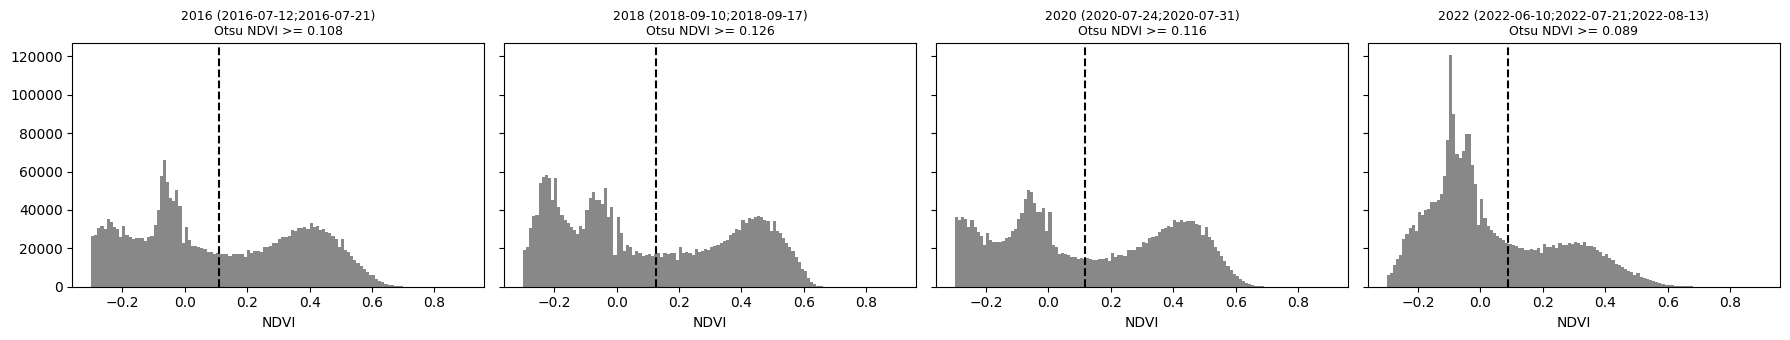

In [5]:
# NDVI histograms of eligible pixels with the threshold used. Bimodal is what we want to see.
fig, axes = plt.subplots(1, len(years), figsize=(4.5 * len(years), 3.5), sharey=True)
for ax, year in zip(np.atleast_1d(axes), years):
    r = results[year]
    ax.hist(r["ndvi"][r["eligible"]], bins=120, range=(-0.3, 0.9), color="#888")
    if r["threshold"] is not None:
        ax.axvline(r["threshold"], color="k", ls="--")
    ax.set_title(f"{year} ({r['acq_dates']})\n{r['method']}", fontsize=9)
    ax.set_xlabel("NDVI")
plt.tight_layout()

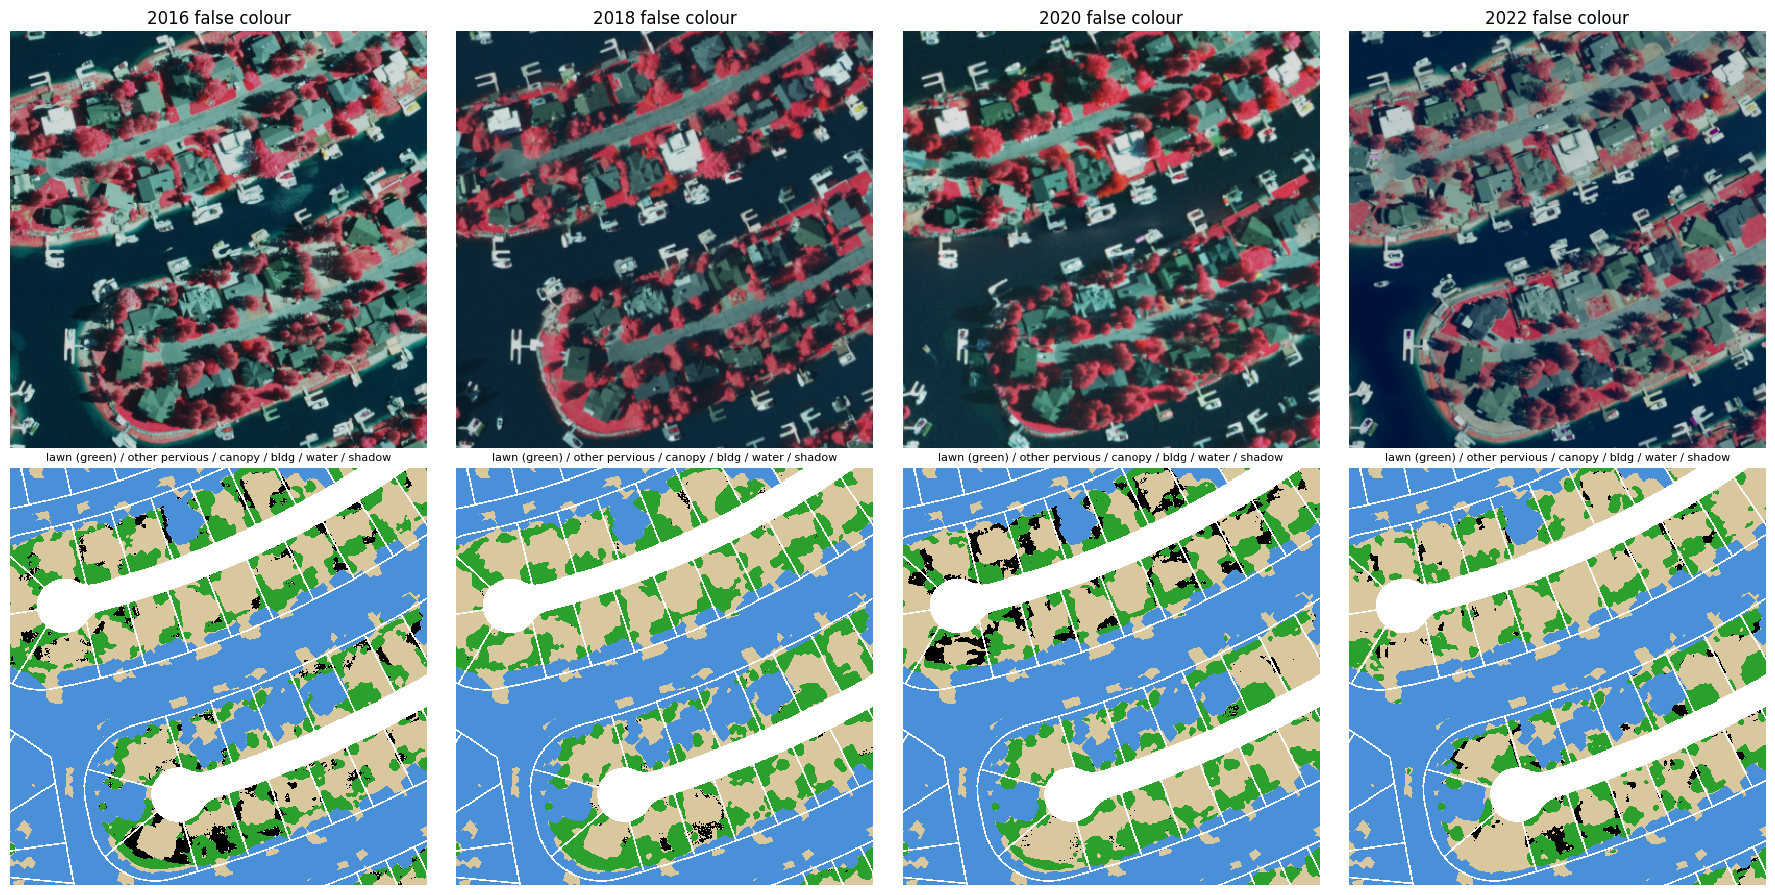

In [6]:
# Visual check on one block: false colour next to the class raster, for the first and last year
def window_of(apn_sample=None, size=400):
    ys, xs = np.where(parcel_id > 0)
    cy, cx = int(np.median(ys)), int(np.median(xs))
    return slice(cy - size // 2, cy + size // 2), slice(cx - size // 2, cx + size // 2)

win = window_of()
cmap = plt.matplotlib.colors.ListedColormap(["white", "#2ca02c", "#d9c79e", "#1f4d1f", "#7f7f7f", "#4a90d9", "#000000"])
fig, axes = plt.subplots(2, len(years), figsize=(4.5 * len(years), 9))
for j, year in enumerate(years):
    arr, _ = G.read_raster(RAW / "naip" / f"naip_{year}.tif", grid)
    fc = np.stack([arr[3], arr[0], arr[1]], axis=-1)[win].astype(float) / 255
    axes[0, j].imshow(fc); axes[0, j].set_title(f"{year} false colour"); axes[0, j].axis("off")
    axes[1, j].imshow(results[year]["cls"][win], cmap=cmap, vmin=0, vmax=6, interpolation="nearest")
    axes[1, j].set_title("lawn (green) / other pervious / canopy / bldg / water / shadow", fontsize=8); axes[1, j].axis("off")
plt.tight_layout()

## Tabulate by parcel

`np.bincount` on the parcel ID raster is the whole zonal statistics step. Areas are in m² and
square feet; percentages use the eligible (pervious, unshaded, unmasked) area as the denominator
so a heavily treed lot is not penalised for its canopy.

In [7]:
def tabulate(mask):
    return np.bincount(parcel_id[mask], minlength=n_parcels + 1)[1:] * PX_M2

inp = parcel_id > 0
static = pd.DataFrame({
    "pid": np.arange(1, n_parcels + 1),
    "raster_m2": tabulate(inp),
    "canopy_m2": tabulate(inp & (canopy == 1)),
    "building_m2": tabulate(inp & (building == 1)),
    "water_m2": tabulate(inp & water),
})

rows = []
for year in years:
    r = results[year]
    date_idx, dtags = G.read_raster(RAW / "naip" / f"naip_{year}_date.tif", grid)
    dates = dtags.get("dates", "").split(";")
    # dominant flight date per parcel: count pixels per (date, parcel), take the argmax
    counts = np.stack([np.bincount(parcel_id[inp & (date_idx == i)], minlength=n_parcels + 1)
                       for i in range(1, len(dates) + 1)])
    dom = counts.argmax(axis=0)  # 0-based date index per parcel
    df = static.copy()
    df["year"] = year
    df["acq_date"] = [dates[d] if counts[:, p].sum() > 0 else None for p, d in enumerate(dom)][1:]
    df["eligible_m2"] = tabulate(r["eligible"])
    df["shadow_m2"] = tabulate(inp & r["shadow"] & (canopy == 0) & (building == 0) & (~water))
    df["lawn_m2"] = tabulate(r["lawn"])
    rows.append(df)

long = pd.concat(rows, ignore_index=True)
long = long.merge(parcels[["pid", "APN", "APO_ADDRESS", "EXISTING_LANDUSE", "ZONING_DESCRIPTION", "parcel_m2",
                           "PARCEL_SQFT", "IMPERVIOUS_SURFACE_SQFT", "BUILDING_SQFT", "YEAR_BUILT", "CATCHMENT"]],
                  on="pid", how="left")
long["lawn_sqft"] = long["lawn_m2"] * 10.7639
long["lawn_pct_eligible"] = np.where(long["eligible_m2"] > 0, long["lawn_m2"] / long["eligible_m2"] * 100, np.nan)
long["lawn_pct_parcel"] = long["lawn_m2"] / long["parcel_m2"] * 100
long["eligible_pct_parcel"] = long["eligible_m2"] / long["parcel_m2"] * 100

cols = ["APN", "pid", "year", "acq_date", "APO_ADDRESS", "EXISTING_LANDUSE", "ZONING_DESCRIPTION", "CATCHMENT", "YEAR_BUILT",
        "parcel_m2", "raster_m2", "eligible_m2", "lawn_m2", "lawn_sqft", "lawn_pct_eligible", "lawn_pct_parcel",
        "eligible_pct_parcel", "canopy_m2", "building_m2", "water_m2", "shadow_m2", "PARCEL_SQFT", "IMPERVIOUS_SURFACE_SQFT", "BUILDING_SQFT"]
long = long[cols].sort_values(["year", "APN"]).reset_index(drop=True)
long.to_parquet(PROC / "lawn_by_parcel_all_years.parquet", index=False)
for year in years:
    long[long["year"] == year].to_csv(OUT / f"lawn_by_parcel_{year}.csv", index=False)
log.info(f"Wrote {len(long):,} parcel-year rows")

summary = (long.groupby(["year", "acq_date"])
           .agg(parcels=("APN", "size"), lawn_acres=("lawn_m2", lambda s: s.sum() / 4046.856),
                eligible_acres=("eligible_m2", lambda s: s.sum() / 4046.856),
                median_lawn_sqft=("lawn_sqft", "median"), parcels_with_lawn=("lawn_m2", lambda s: (s >= cfg["change"]["lawn_present_min_m2"]).sum()))
           .reset_index())
summary["lawn_pct_of_eligible"] = summary["lawn_acres"] / summary["eligible_acres"] * 100
summary.to_csv(OUT / "lawn_summary_by_year.csv", index=False)
summary

2026-09-17 21:38:26 | INFO | 02_classify | Wrote 5,800 parcel-year rows


,year,acq_date,parcels,lawn_acres,eligible_acres,median_lawn_sqft,parcels_with_lawn,lawn_pct_of_eligible
0,2016,2016-07-12,1450,91.691980,221.353169,1613.939166,1100,41.423387
1,2018,2018-09-17,1450,98.892236,236.468103,1675.939230,1094,41.820540
2,2020,2020-07-24,6,0.625285,1.809227,1726.314282,4,34.560920
3,2020,2020-07-31,1444,94.137968,221.068504,1681.751736,1100,42.583166
4,2022,2022-07-21,1450,65.995321,223.876995,1067.563602,1035,29.478384


## QA

In [8]:
checks = {
    "nulls": qa.check_nulls(long, ["APN", "year", "lawn_m2", "eligible_m2"]),
    "duplicates": qa.check_duplicates(long, ["APN", "year"]),
    "row_count": qa.check_row_count(long, expected_min=1400 * len(years), expected_max=1500 * len(years)),
    "lawn_exceeds_eligible": int((long["lawn_m2"] > long["eligible_m2"] + 1e-6).sum()),
    "parcels_no_eligible_area": int((long.groupby("APN")["eligible_m2"].max() == 0).sum()),
    "parcels_eligible_under_10pct": int((long.groupby("APN")["eligible_pct_parcel"].max() < 10).sum()),
}
# Impervious sanity: parcel-table impervious + our eligible pervious should not exceed the parcel by much
chk = long[long["year"] == years[-1]].copy()
chk["imperv_m2"] = chk["IMPERVIOUS_SURFACE_SQFT"].fillna(0) / 10.7639
chk["over"] = (chk["imperv_m2"] + chk["eligible_m2"] + chk["canopy_m2"]) / chk["parcel_m2"]
checks["parcels_over_120pct_area_budget"] = int((chk["over"] > 1.2).sum())
for k, v in checks.items():
    log.info(f"QA {k}: {v}")
pd.json_normalize(checks).T.to_csv(OUT / "qa_02_classify.csv", header=False)

# Parcels worth a look: little eligible area, or lawn share swinging wildly between adjacent years
flag = (long.pivot(index="APN", columns="year", values="lawn_pct_eligible"))
swing = flag.diff(axis=1).abs().max(axis=1)
review = long[long["APN"].isin(swing[swing > 60].index)][["APN", "APO_ADDRESS", "year", "acq_date", "lawn_sqft", "lawn_pct_eligible", "eligible_pct_parcel"]]
review.to_csv(OUT / "qa_02_review_large_swings.csv", index=False)
log.info(f"{review['APN'].nunique()} parcels with a >60 point swing in lawn share between image years, written for review")
log.info("02_classify complete")

2026-09-17 21:38:26 | INFO | 02_classify | QA nulls: {'APN': 0, 'year': 0, 'lawn_m2': 0, 'eligible_m2': 0}


2026-09-17 21:38:26 | INFO | 02_classify | QA duplicates: {'key_cols': ['APN', 'year'], 'duplicate_rows': 0}


2026-09-17 21:38:26 | INFO | 02_classify | QA row_count: {'rows': 5800, 'expected_min': 5600, 'expected_max': 6000, 'status': 'ok'}


2026-09-17 21:38:26 | INFO | 02_classify | QA lawn_exceeds_eligible: 0


2026-09-17 21:38:26 | INFO | 02_classify | QA parcels_no_eligible_area: 10


2026-09-17 21:38:26 | INFO | 02_classify | QA parcels_eligible_under_10pct: 44


2026-09-17 21:38:26 | INFO | 02_classify | QA parcels_over_120pct_area_budget: 0


2026-09-17 21:38:26 | INFO | 02_classify | 16 parcels with a >60 point swing in lawn share between image years, written for review


2026-09-17 21:38:26 | INFO | 02_classify | 02_classify complete
